In [57]:
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv('train.csv')

In [14]:
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,1
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,1


In [7]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [80]:
test = pd.read_csv('test.csv')

In [18]:
df['title'] = np.where(df['Name'].str.contains("Mr.",case=False,na=np.nan),1,0)


In [82]:
conditions = [
    test['Name'].str.contains("Miss", case=False, na=False),
    test['Name'].str.contains("Mrs.", case=False, na=False),
    test['Name'].str.contains("Mr.", case=False, na=False)
]

In [83]:
match = [1,2,3]
test['title'] = np.select(conditions,match, default=0)

In [84]:
test['title'].value_counts()

title
3    240
1     78
2     72
0     28
Name: count, dtype: int64

In [24]:
dfe = df.copy()

In [85]:
test.drop(columns=['Name','SibSp','Parch','Cabin'],inplace=True)

In [86]:
test.drop(['Ticket'],inplace=True,axis=1)

In [87]:
test

,PassengerId,Pclass,Sex,Age,Fare,Embarked,title
0,892,3,male,34.5,7.8292,Q,3
1,893,3,female,47.0,7.0000,S,2
2,894,2,male,62.0,9.6875,Q,3
3,895,3,male,27.0,8.6625,S,3
4,896,3,female,22.0,12.2875,S,2
...,...,...,...,...,...,...,...
413,1305,3,male,NaN,8.0500,S,3
414,1306,1,female,39.0,108.9000,C,0
415,1307,3,male,38.5,7.2500,S,3
416,1308,3,male,NaN,8.0500,S,3


In [ ]:
df

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,title
0,1,0,3,male,22.0,7.2500,S,3
1,2,1,1,female,38.0,71.2833,C,2
2,3,1,3,female,26.0,7.9250,S,1
3,4,1,1,female,35.0,53.1000,S,2
4,5,0,3,male,35.0,8.0500,S,3
...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,13.0000,S,0
887,888,1,1,female,19.0,30.0000,S,1
888,889,0,3,female,NaN,23.4500,S,1
889,890,1,1,male,26.0,30.0000,C,3


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   Fare         891 non-null    float64
 6   Embarked     889 non-null    object 
 7   title        891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [32]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [33]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [88]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
le = lb.fit_transform(test[['Sex']])

c:\p\ven\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [89]:
test['sexx'] = le

In [91]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   Age          332 non-null    float64
 4   Fare         417 non-null    float64
 5   Embarked     418 non-null    object 
 6   title        418 non-null    int64  
 7   sexx         418 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 26.3+ KB


In [92]:
le = lb.fit_transform(test[['Embarked']])
test['emb'] = le

c:\p\ven\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [93]:
le

array([1, 2, 1, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 0, 1, 0, 2, 0, 0, 2,
       2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 0, 1, 0, 2, 2, 0, 2, 2, 0, 1, 2, 2, 2, 0, 2, 2, 2, 1, 0, 2,
       1, 2, 0, 2, 1, 2, 2, 0, 0, 0, 2, 2, 2, 1, 0, 2, 2, 2, 1, 0, 1, 2,
       1, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 1, 2, 0, 2, 1, 1, 2, 2,
       0, 1, 0, 1, 2, 0, 0, 2, 0, 2, 2, 1, 0, 2, 1, 2, 2, 1, 2, 2, 2, 0,
       2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 2,
       2, 0, 2, 0, 2, 0, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2,
       2, 2, 1, 2, 0, 2, 2, 0, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2,
       0, 2, 2, 2, 0, 0, 2, 1, 2, 2, 2, 2, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2,
       0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 2, 2, 2, 2, 0, 1, 0, 1, 0, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2,
       2, 2, 0, 2, 2, 1, 0, 2, 2, 2, 0, 0, 2, 2, 2,

In [94]:
test.drop(['Sex','Embarked'], axis=1,inplace=True)

In [95]:
test.head()

,PassengerId,Pclass,Age,Fare,title,sexx,emb
0,892,3,34.5,7.8292,3,1,1
1,893,3,47.0,7.0000,2,0,2
2,894,2,62.0,9.6875,3,1,1
3,895,3,27.0,8.6625,3,1,2
4,896,3,22.0,12.2875,2,0,2


In [51]:
df[df.isnull().any(axis=1)]

,PassengerId,Survived,Pclass,Age,Fare,title,sexx,emb
5,6,0,3,NaN,8.4583,3,1,1
17,18,1,2,NaN,13.0000,3,1,2
19,20,1,3,NaN,7.2250,2,0,0
26,27,0,3,NaN,7.2250,3,1,0
28,29,1,3,NaN,7.8792,1,0,1
...,...,...,...,...,...,...,...,...
859,860,0,3,NaN,7.2292,3,1,0
863,864,0,3,NaN,69.5500,1,0,2
868,869,0,3,NaN,9.5000,3,1,2
878,879,0,3,NaN,7.8958,3,1,2


In [55]:
df.corr()

,PassengerId,Survived,Pclass,Age,Fare,title,sexx,emb
PassengerId,1.000000,-0.005007,-0.035144,0.036847,0.012658,0.040778,0.042939,0.013083
Survived,-0.005007,1.000000,-0.338481,-0.077221,0.257307,-0.431837,-0.543351,-0.163517
Pclass,-0.035144,-0.338481,1.000000,-0.369226,-0.549500,0.094232,0.131900,0.157112
Age,0.036847,-0.077221,-0.369226,1.000000,0.096067,0.323763,0.093254,-0.025252
Fare,0.012658,0.257307,-0.549500,0.096067,1.000000,-0.147176,-0.182333,-0.221226
title,0.040778,-0.431837,0.094232,0.323763,-0.147176,1.000000,0.617613,0.074179
sexx,0.042939,-0.543351,0.131900,0.093254,-0.182333,0.617613,1.000000,0.104057
emb,0.013083,-0.163517,0.157112,-0.025252,-0.221226,0.074179,0.104057,1.000000


In [97]:
x_test = test[['Pclass','Fare','title','sexx','emb']]


In [56]:
x = df[['Pclass','Fare','title','sexx','emb']]
y = df['Survived']

<Axes: >

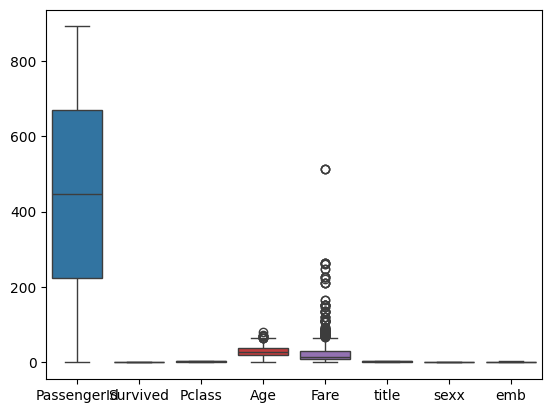

In [59]:
sns.boxplot(df)

In [115]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
scaled = std.fit_transform(x)

In [116]:
scaled_test = std.transform(x_test)

In [117]:
df_scaled_test = pd.DataFrame(scaled_test,columns=['Pclass','Fare','title','sexx','emb'])

In [118]:
df_scaled = pd.DataFrame(scaled,columns=['Pclass','Fare','title','sexx','emb'])

In [119]:
df_scaled.isnull().any(axis=1)

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [120]:
df_scaled

,Pclass,Fare,title,sexx,emb
0,0.827377,-0.502445,0.759578,0.737695,0.581114
1,-1.566107,0.786845,-0.231321,-1.355574,-1.938460
2,0.827377,-0.488854,-1.222219,-1.355574,0.581114
3,-1.566107,0.420730,-0.231321,-1.355574,0.581114
4,0.827377,-0.486337,0.759578,0.737695,0.581114
...,...,...,...,...,...
886,-0.369365,-0.386671,-2.213117,0.737695,0.581114
887,-1.566107,-0.044381,-1.222219,-1.355574,0.581114
888,0.827377,-0.176263,-1.222219,-1.355574,0.581114
889,-1.566107,-0.044381,0.759578,0.737695,-1.938460


In [121]:
df_scaled_test

,Pclass,Fare,title,sexx,emb
0,0.827377,-0.490783,0.759578,0.737695,-0.678673
1,0.827377,-0.507479,-0.231321,-1.355574,0.581114
2,-0.369365,-0.453367,0.759578,0.737695,-0.678673
3,0.827377,-0.474005,0.759578,0.737695,0.581114
4,0.827377,-0.401017,-0.231321,-1.355574,0.581114
...,...,...,...,...,...
413,0.827377,-0.486337,0.759578,0.737695,0.581114
414,-1.566107,1.544246,-2.213117,-1.355574,-1.938460
415,0.827377,-0.502445,0.759578,0.737695,0.581114
416,0.827377,-0.486337,0.759578,0.737695,0.581114


In [122]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()

In [123]:
log.fit(x,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [126]:
df_scaled_test.isnull().any(axis=0)

Pclass    False
Fare      False
title     False
sexx      False
emb       False
dtype: bool

In [111]:
df_scaled_test[df_scaled_test['Fare'].isnull()]

,Pclass,Fare,title,sexx,emb


In [125]:
df_scaled_test.drop(index=152,axis=0,inplace=True)

In [127]:
y_pred = log.predict(df_scaled_test)

In [128]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,